In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [2]:
data = pd.read_csv("QVI_data.csv")

In [3]:
data["DATE"] = pd.to_datetime(data["DATE"])

In [4]:
data["YEARMONTH"] = data["DATE"].dt.year * 100 + data["DATE"].dt.month

In [5]:
print(data["YEARMONTH"].unique())

[201810 201809 201903 201811 201812 201807 201906 201904 201901 201808
 201905 201902]


In [6]:
print(data["STORE_NBR"].nunique(), "stores")

272 stores


In [7]:
monthly_metrics = data.groupby(["STORE_NBR", "YEARMONTH"]).agg(
    TOT_SALES=("TOT_SALES", "sum"),
    N_CUSTOMERS=("LYLTY_CARD_NBR", "nunique"),
    N_TXNS=("TXN_ID", "nunique"),
    N_TXN_PER_CUST=("TXN_ID", "nunique")  # temp, will fix below
).reset_index()

In [8]:
# Average transactions per customer
monthly_metrics["TXN_PER_CUST"] = monthly_metrics["N_TXNS"] / monthly_metrics["N_CUSTOMERS"]


In [9]:
print(monthly_metrics.shape)

(3169, 7)


In [10]:
print(monthly_metrics.head(10))

   STORE_NBR  YEARMONTH  TOT_SALES  N_CUSTOMERS  N_TXNS  N_TXN_PER_CUST  \
0          1     201807      206.9           49      52              52   
1          1     201808      176.1           42      43              43   
2          1     201809      278.8           59      62              62   
3          1     201810      188.1           44      45              45   
4          1     201811      192.6           46      47              47   
5          1     201812      189.6           42      47              47   
6          1     201901      154.8           35      36              36   
7          1     201902      225.4           52      55              55   
8          1     201903      192.9           45      49              49   
9          1     201904      192.9           42      43              43   

   TXN_PER_CUST  
0      1.061224  
1      1.023810  
2      1.050847  
3      1.022727  
4      1.021739  
5      1.119048  
6      1.028571  
7      1.057692  
8      1.088

In [11]:
months_per_store = monthly_metrics.groupby("STORE_NBR")["YEARMONTH"].count()
full_stores = months_per_store[months_per_store == 12].index

In [12]:
print("Stores with full 12 months:", len(full_stores))

Stores with full 12 months: 260


In [13]:
monthly_metrics_full = monthly_metrics[monthly_metrics["STORE_NBR"].isin(full_stores)]
print(monthly_metrics_full.shape)

(3120, 7)


In [14]:
print([s for s in [77, 86, 88] if s in full_stores])

[77, 86, 88]


In [15]:
pretrial_months = [201807,201808,201809,201810,201811,201812,201901]

In [16]:
pretrial = monthly_metrics_full[monthly_metrics_full["YEARMONTH"].isin(pretrial_months)]

In [17]:

def calculate_correlation(pretrial_df, metric_col, trial_store):
    trial_data = pretrial_df[pretrial_df["STORE_NBR"] == trial_store].set_index("YEARMONTH")[metric_col]
    
    results = []
    for store in pretrial_df["STORE_NBR"].unique():
        if store == trial_store:
            continue
        control_data = pretrial_df[pretri
        al_df["STORE_NBR"] == store].set_index("YEARMONTH")[metric_col]
        corr = trial_data.corr(control_data)
        results.append({"STORE_NBR": store, "corr_measure": corr})
    
    return pd.DataFrame(results)

In [18]:
corr_sales_77 = calculate_correlation(pretrial, "TOT_SALES", 77)
print(corr_sales_77.sort_values("corr_measure", ascending=False).head(10))

     STORE_NBR  corr_measure
67          71      0.914106
220        233      0.903774
110        119      0.867664
15          17      0.842668
2            3      0.806644
38          41      0.783232
46          50      0.763866
148        157      0.735893
153        162      0.729740
243        257      0.724927


In [25]:
def calculate_magnitude_distance(pretrial_df, metric_col, trial_store):
    trial_data = pretrial_df[pretrial_df["STORE_NBR"] == trial_store].set_index("YEARMONTH")[metric_col]
    results = []
    for store in pretrial_df["STORE_NBR"].unique():
        if store == trial_store:
            continue
        control_data = pretrial_df[pretrial_df["STORE_NBR"] == store].set_index("YEARMONTH")[metric_col]
        abs_diff = (trial_data - control_data).abs().mean()
        results.append({"STORE_NBR": store, "abs_diff": abs_diff})
    dist_df = pd.DataFrame(results)
    min_d = dist_df["abs_diff"].min()
    max_d = dist_df["abs_diff"].max()
    dist_df["mag_measure"] = 1 - (dist_df["abs_diff"] - min_d) / (max_d - min_d)
    return dist_df

In [26]:
mag_sales_77 = calculate_magnitude_distance(pretrial, "TOT_SALES", 77)
print(mag_sales_77.sort_values("mag_measure", ascending=False).head(10))

     STORE_NBR   abs_diff  mag_measure
220        233  18.828571     1.000000
241        255  28.571429     0.991889
179        188  31.100000     0.989784
49          53  32.471429     0.988642
122        131  33.042857     0.988167
42          46  33.228571     0.988012
202        214  34.442857     0.987001
46          50  34.714286     0.986775
195        205  36.057143     0.985657
178        187  37.685714     0.984301


In [27]:
def get_control_store(pretrial_df, metric_col, trial_store, weight_corr=0.5, weight_mag=0.5):
    corr_df = calculate_correlation(pretrial_df, metric_col, trial_store)
    mag_df = calculate_magnitude_distance(pretrial_df, metric_col, trial_store)
    
    combined = corr_df.merge(mag_df, on="STORE_NBR")
    combined["score"] = weight_corr * combined["corr_measure"] + weight_mag * combined["mag_measure"]
    
    return combined.sort_values("score", ascending=False)

scores_77 = get_control_store(pretrial, "TOT_SALES", 77)
print(scores_77.head(10))

     STORE_NBR  corr_measure    abs_diff  mag_measure     score
220        233      0.903774   18.828571     1.000000  0.951887
38          41      0.783232   45.342857     0.977927  0.880579
46          50      0.763866   34.714286     0.986775  0.875320
15          17      0.842668  155.614286     0.886125  0.864397
107        115      0.689159   87.657143     0.942700  0.815929
158        167      0.657110   53.485714     0.971148  0.814129
251        265      0.639759   48.271429     0.975489  0.807624
221        234      0.696325  143.685714     0.896056  0.796190
49          53      0.532764   32.471429     0.988642  0.760703
78          84      0.684348  219.928571     0.832583  0.758465


In [28]:
def get_control_store_multi(pretrial_df, trial_store, metrics=["TOT_SALES","N_CUSTOMERS","TXN_PER_CUST"]):
    all_scores = None
    for metric in metrics:
        scores = get_control_store(pretrial_df, metric, trial_store)[["STORE_NBR","score"]]
        scores = scores.rename(columns={"score": f"score_{metric}"})
        if all_scores is None:
            all_scores = scores
        else:
            all_scores = all_scores.merge(scores, on="STORE_NBR")
    
    score_cols = [c for c in all_scores.columns if c.startswith("score_")]
    all_scores["final_score"] = all_scores[score_cols].mean(axis=1)
    return all_scores.sort_values("final_score", ascending=False)

control_77 = get_control_store_multi(pretrial, 77)
print(control_77.head(10))

C:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


    STORE_NBR  score_TOT_SALES  score_N_CUSTOMERS  score_TXN_PER_CUST  \
3          17         0.864397           0.858222            0.684392   
9          84         0.758465           0.893020            0.670811   
20        145         0.689454           0.820516            0.782399   
4         115         0.815929           0.844780            0.623858   
29         37         0.655673           0.711514            0.856030   
33        248         0.631211           0.807019            0.730719   
0         233         0.951887           0.995179            0.221718   
5         167         0.814129           0.836580            0.493785   
24        176         0.673940           0.509122            0.927979   
7         234         0.796190           0.766486            0.539961   

    final_score  
3      0.802337  
9      0.774099  
20     0.764123  
4      0.761523  
29     0.741072  
33     0.722983  
0      0.722928  
5      0.714831  
24     0.703680  
7      0.700879 

In [29]:
print(pretrial[pretrial["STORE_NBR"]==233]["TXN_PER_CUST"])
print(pretrial.groupby("STORE_NBR")["TXN_PER_CUST"].std().sort_values().head(10))

2699    1.058824
2700    1.041667
2701    1.071429
2702    1.028571
2703    1.025000
2704    1.063830
2705    1.000000
Name: TXN_PER_CUST, dtype: float64
STORE_NBR
244    0.0
61     0.0
52     0.0
42     0.0
127    0.0
139    0.0
224    0.0
99     0.0
258    0.0
198    0.0
Name: TXN_PER_CUST, dtype: float64


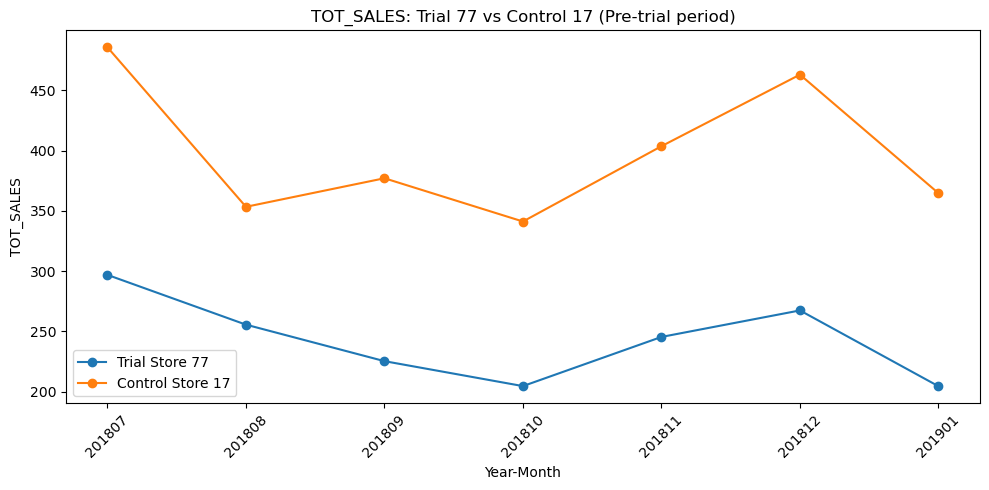

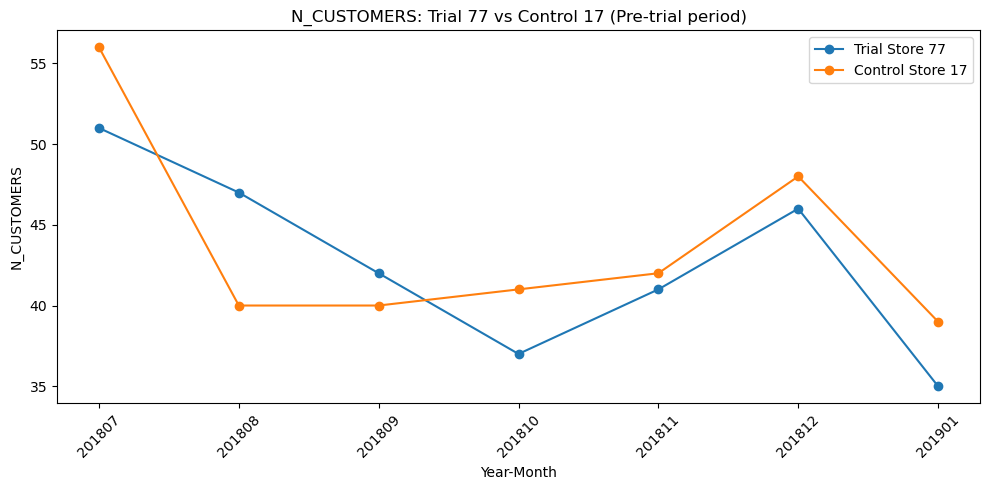

In [30]:
def plot_trial_vs_control(pretrial_df, metric_col, trial_store, control_store):
    trial_data = pretrial_df[pretrial_df["STORE_NBR"]==trial_store].sort_values("YEARMONTH")
    control_data = pretrial_df[pretrial_df["STORE_NBR"]==control_store].sort_values("YEARMONTH")
    
    plt.figure(figsize=(10,5))
    plt.plot(trial_data["YEARMONTH"].astype(str), trial_data[metric_col], marker="o", label=f"Trial Store {trial_store}")
    plt.plot(control_data["YEARMONTH"].astype(str), control_data[metric_col], marker="o", label=f"Control Store {control_store}")
    plt.title(f"{metric_col}: Trial {trial_store} vs Control {control_store} (Pre-trial period)")
    plt.xlabel("Year-Month")
    plt.ylabel(metric_col)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_trial_vs_control(pretrial, "TOT_SALES", 77, 17)
plot_trial_vs_control(pretrial, "N_CUSTOMERS", 77, 17)

In [31]:
def get_control_store_weighted(pretrial_df, trial_store):
    scores_sales = get_control_store(pretrial_df, "TOT_SALES", trial_store)[["STORE_NBR","score"]].rename(columns={"score":"score_sales"})
    scores_cust  = get_control_store(pretrial_df, "N_CUSTOMERS", trial_store)[["STORE_NBR","score"]].rename(columns={"score":"score_cust"})
    scores_txn   = get_control_store(pretrial_df, "TXN_PER_CUST", trial_store)[["STORE_NBR","score"]].rename(columns={"score":"score_txn"})
    
    combined = scores_sales.merge(scores_cust, on="STORE_NBR").merge(scores_txn, on="STORE_NBR")
    
    # zyada weight sales aur customers ko, kam weight noisy txn_per_cust ko
    combined["final_score"] = (
        0.5 * combined["score_sales"] +
        0.35 * combined["score_cust"] +
        0.15 * combined["score_txn"].fillna(0)
    )
    return combined.sort_values("final_score", ascending=False)

control_77_v2 = get_control_store_weighted(pretrial, 77)
print(control_77_v2.head(10))

C:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


    STORE_NBR  score_sales  score_cust  score_txn  final_score
0         233     0.951887    0.995179   0.221718     0.857514
3          17     0.864397    0.858222   0.684392     0.835235
4         115     0.815929    0.844780   0.623858     0.797217
9          84     0.758465    0.893020   0.670811     0.792411
1          41     0.880579    0.912850   0.186702     0.787793
5         167     0.814129    0.836580   0.493785     0.773935
20        145     0.689454    0.820516   0.782399     0.749267
10        254     0.754326    0.928783   0.313196     0.749217
7         234     0.796190    0.766486   0.539961     0.747360
11        111     0.748771    0.829074   0.459226     0.733445


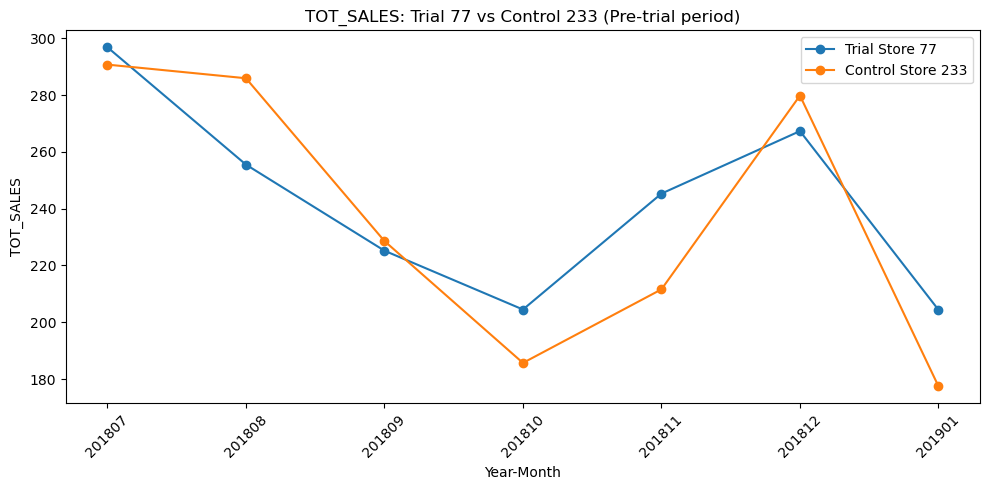

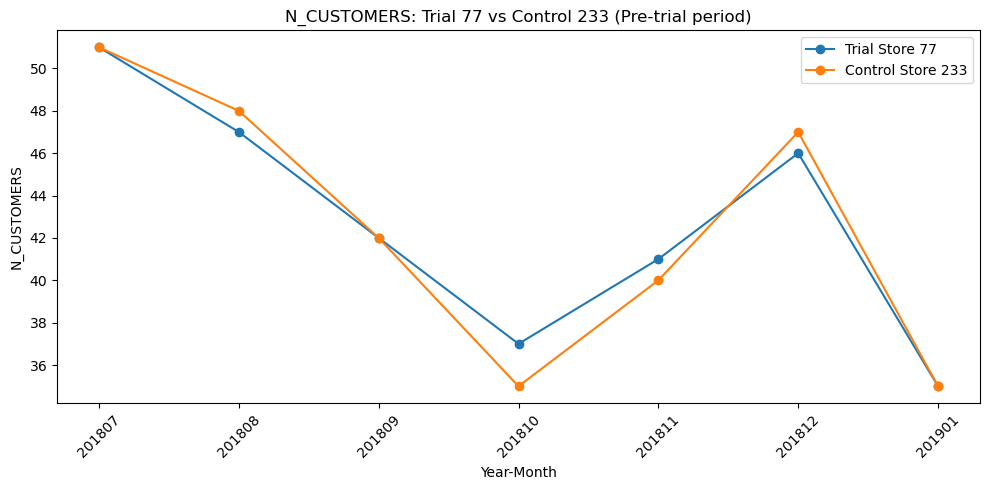

In [32]:
plot_trial_vs_control(pretrial, "TOT_SALES", 77, 233)
plot_trial_vs_control(pretrial, "N_CUSTOMERS", 77, 233)

In [33]:
control_86_v2 = get_control_store_weighted(pretrial, 86)
print(control_86_v2.head(10))

C:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


    STORE_NBR  score_sales  score_cust  score_txn  final_score
0         155     0.938423    0.971438   0.354823     0.862438
3         138     0.859483    0.845350   0.720934     0.833754
4         114     0.844751    0.901951   0.551526     0.820787
2         109     0.894150    0.875555   0.224814     0.787241
7         225     0.805183    0.857062   0.358176     0.756290
1         222     0.894964    0.695080   0.269302     0.731155
23         75     0.713052    0.755792   0.604752     0.711766
19        172     0.740062    0.759037   0.499904     0.710679
20        229     0.726716    0.727699   0.609789     0.709521
16         32     0.744380    0.636693   0.725273     0.703824


In [34]:
control_88_v2 = get_control_store_weighted(pretrial, 88)
print(control_88_v2.head(10))

C:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


    STORE_NBR  score_sales  score_cust  score_txn  final_score
4         178     0.728884    0.884324   0.597168     0.763530
5         201     0.702425    0.721250   0.780996     0.720799
8         237     0.654240    0.973663   0.306244     0.713839
10        123     0.647417    0.766513   0.629791     0.686457
19        113     0.604013    0.826927   0.623202     0.684911
1         203     0.750972    0.619400   0.548776     0.674592
21         69     0.594328    0.847398   0.469808     0.664225
6         106     0.687683    0.527287   0.865123     0.658161
2          91     0.733564    0.436382   0.595418     0.608828
15         26     0.619799    0.630513   0.278717     0.572387


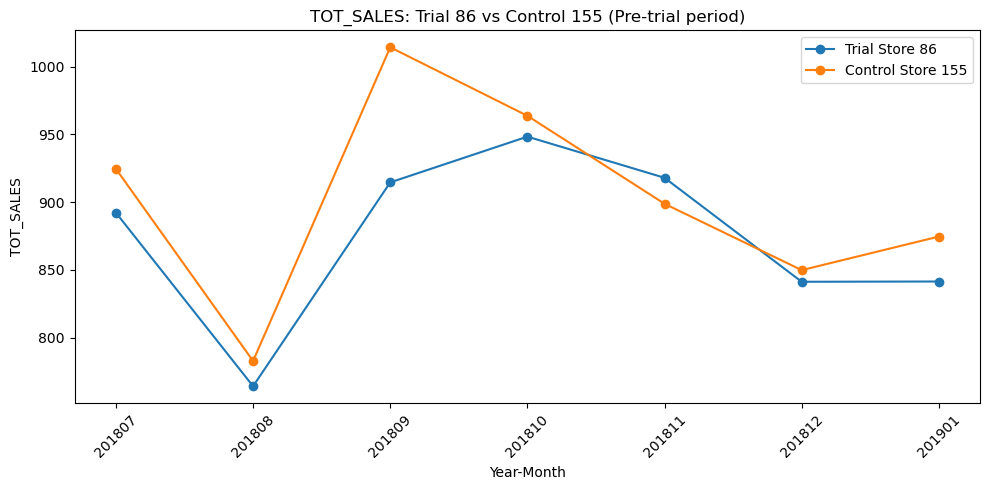

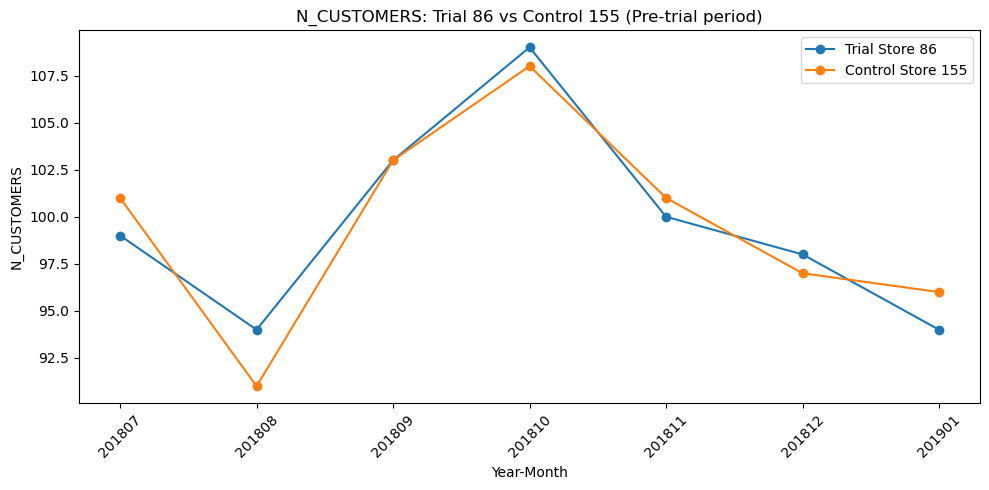

In [37]:
plot_trial_vs_control(pretrial, "TOT_SALES", 86, 155)
plot_trial_vs_control(pretrial, "N_CUSTOMERS", 86, 155)

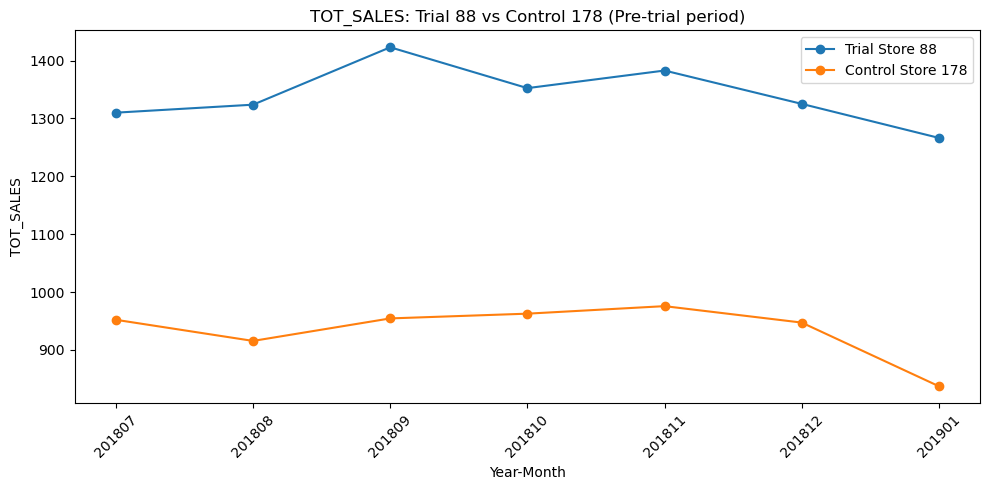

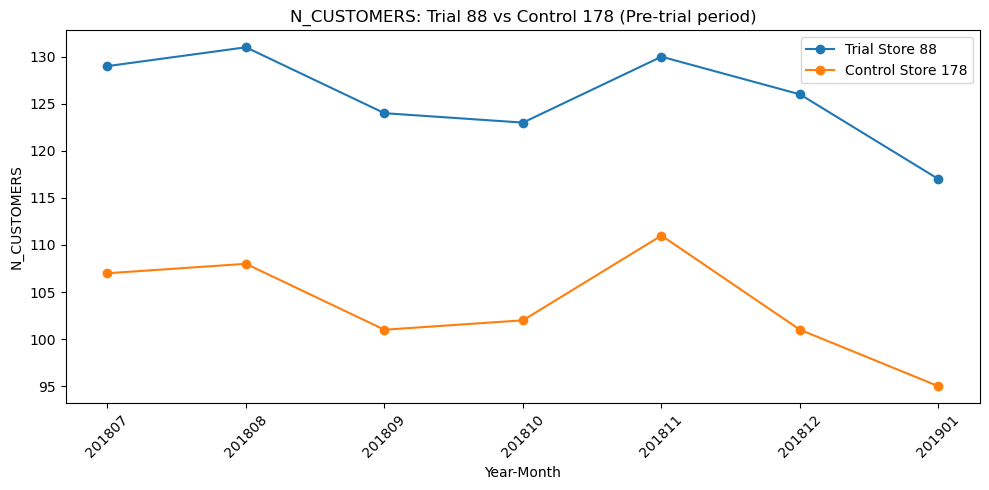

In [38]:
plot_trial_vs_control(pretrial, "TOT_SALES", 88, 178)
plot_trial_vs_control(pretrial, "N_CUSTOMERS", 88, 178)

In [39]:
control_88_v2 = get_control_store_weighted(pretrial, 88)
print(control_88_v2.head(8))

C:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


    STORE_NBR  score_sales  score_cust  score_txn  final_score
4         178     0.728884    0.884324   0.597168     0.763530
5         201     0.702425    0.721250   0.780996     0.720799
8         237     0.654240    0.973663   0.306244     0.713839
10        123     0.647417    0.766513   0.629791     0.686457
19        113     0.604013    0.826927   0.623202     0.684911
1         203     0.750972    0.619400   0.548776     0.674592
21         69     0.594328    0.847398   0.469808     0.664225
6         106     0.687683    0.527287   0.865123     0.658161


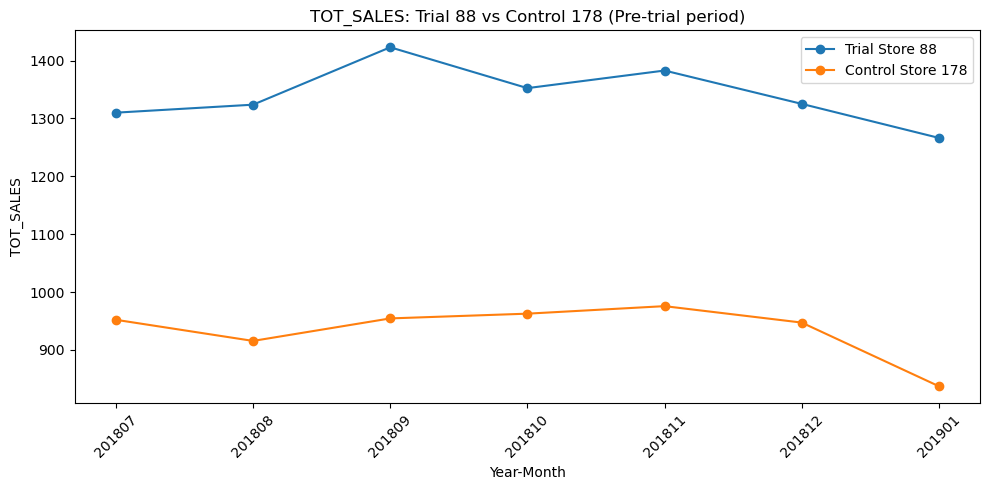

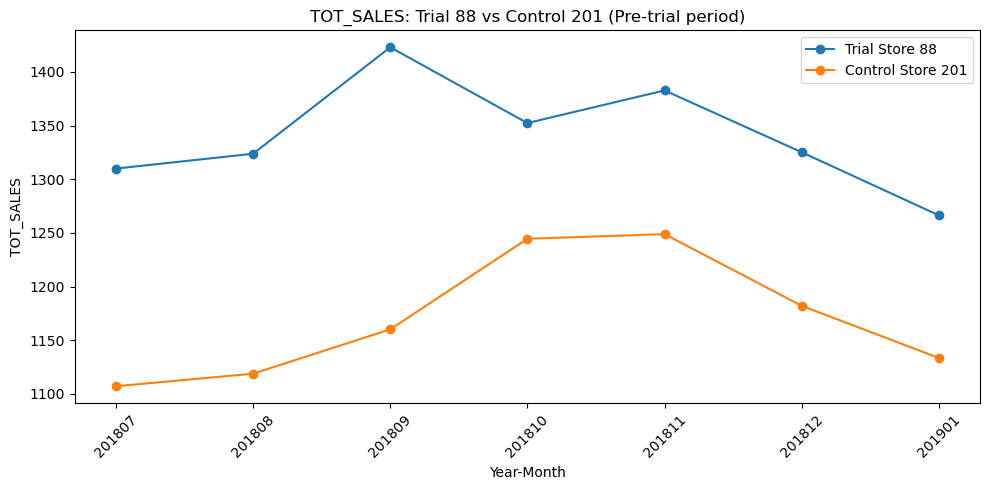

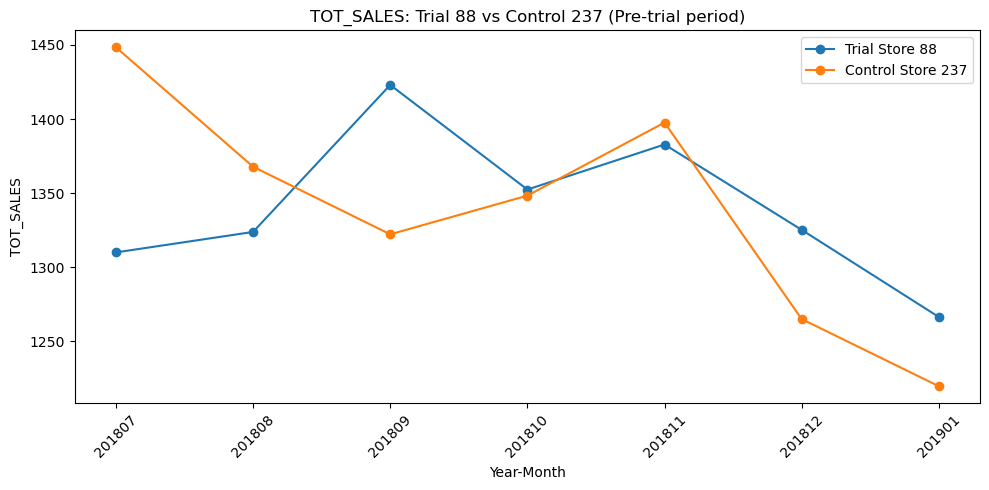

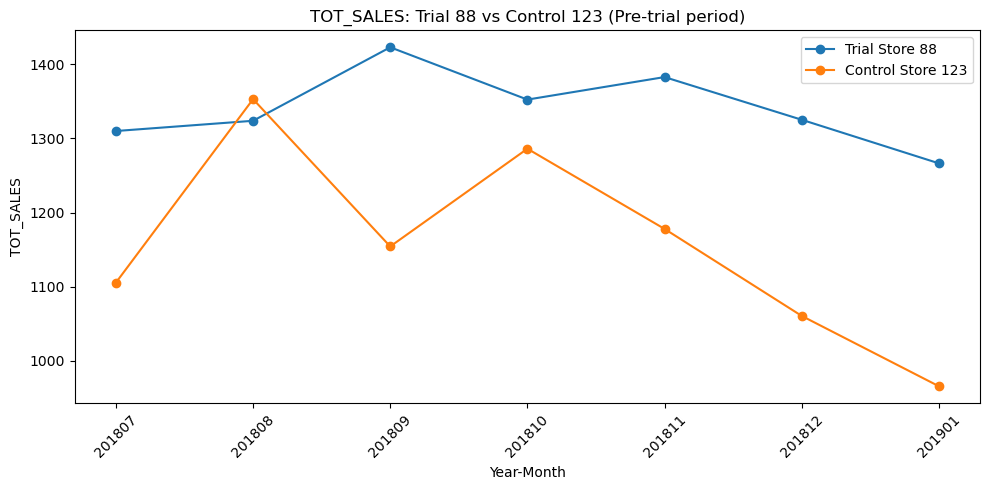

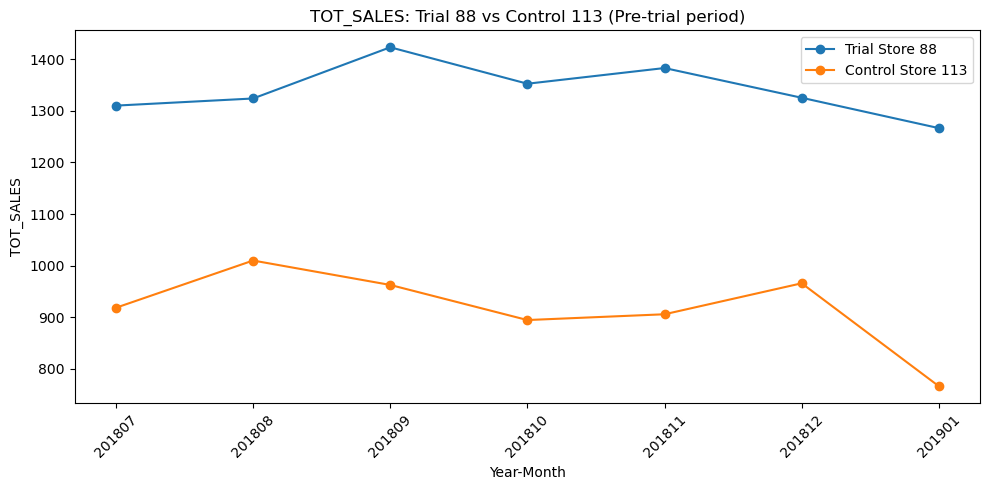

In [41]:
for candidate in control_88_v2["STORE_NBR"].head(5):
    plot_trial_vs_control(pretrial, "TOT_SALES", 88, candidate)

In [42]:
# Check karo store 88 average sales kitna hai vs candidates
for s in [88, 178, 201, 237, 123, 113]:
    avg = pretrial[pretrial["STORE_NBR"]==s]["TOT_SALES"].mean()
    print(f"Store {s}: avg pretrial sales = {avg:.1f}")
    

Store 88: avg pretrial sales = 1340.5
Store 178: avg pretrial sales = 934.9
Store 201: avg pretrial sales = 1170.8
Store 237: avg pretrial sales = 1338.4
Store 123: avg pretrial sales = 1157.5
Store 113: avg pretrial sales = 917.6


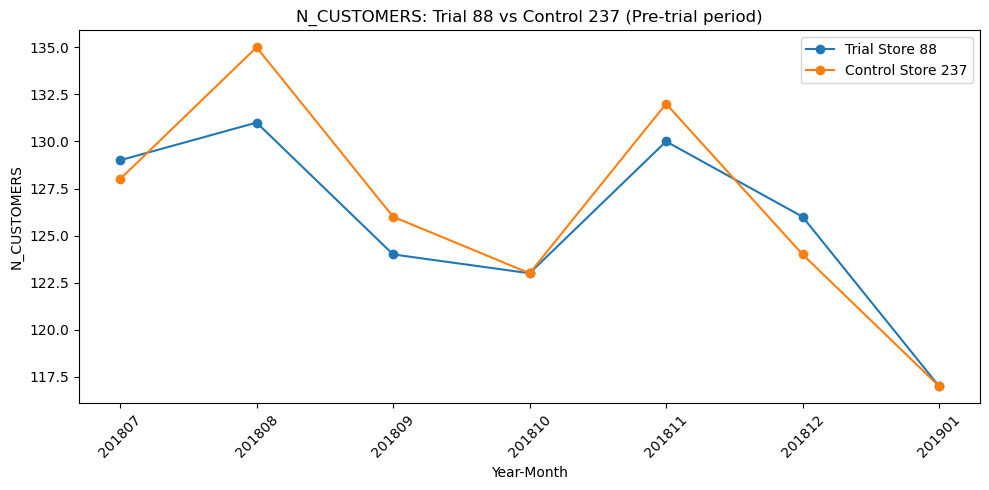

In [44]:
plot_trial_vs_control(pretrial, "N_CUSTOMERS", 88, 237)

In [45]:
trial_months = [201902, 201903, 201904]

trial_period = monthly_metrics_full[monthly_metrics_full["YEARMONTH"].isin(trial_months)]

def compare_trial_vs_control(trial_period_df, trial_store, control_store, metric_col="TOT_SALES"):
    trial_data = trial_period_df[trial_period_df["STORE_NBR"]==trial_store].sort_values("YEARMONTH")
    control_data = trial_period_df[trial_period_df["STORE_NBR"]==control_store].sort_values("YEARMONTH")
    
    comparison = pd.DataFrame({
        "YEARMONTH": trial_data["YEARMONTH"].values,
        f"Trial_{trial_store}": trial_data[metric_col].values,
        f"Control_{control_store}": control_data[metric_col].values,
    })
    comparison["pct_uplift"] = (
        (comparison[f"Trial_{trial_store}"] - comparison[f"Control_{control_store}"])
        / comparison[f"Control_{control_store}"] * 100
    )
    return comparison

result_77 = compare_trial_vs_control(trial_period, 77, 233, "TOT_SALES")
print(result_77)

   YEARMONTH  Trial_77  Control_233  pct_uplift
0     201902     235.0        244.0   -3.688525
1     201903     278.5        199.1   39.879458
2     201904     263.5        158.6   66.141236


In [46]:
def calc_scaling_factor(pretrial_df, trial_store, control_store, metric_col="TOT_SALES"):
    trial_avg = pretrial_df[pretrial_df["STORE_NBR"]==trial_store][metric_col].mean()
    control_avg = pretrial_df[pretrial_df["STORE_NBR"]==control_store][metric_col].mean()
    return trial_avg / control_avg

scale_77 = calc_scaling_factor(pretrial, 77, 233, "TOT_SALES")
print("Scaling factor:", scale_77)

Scaling factor: 1.0236173032895532


In [47]:
def get_pretrial_pct_diff(pretrial_df, trial_store, control_store, metric_col="TOT_SALES"):
    scale = calc_scaling_factor(pretrial_df, trial_store, control_store, metric_col)
    
    trial_data = pretrial_df[pretrial_df["STORE_NBR"]==trial_store].sort_values("YEARMONTH")
    control_data = pretrial_df[pretrial_df["STORE_NBR"]==control_store].sort_values("YEARMONTH")
    
    scaled_control = control_data[metric_col].values * scale
    pct_diff = (trial_data[metric_col].values - scaled_control) / scaled_control * 100
    
    return pct_diff

pct_diff_77 = get_pretrial_pct_diff(pretrial, 77, 233, "TOT_SALES")
print("Pre-trial % differences (baseline noise):", pct_diff_77)
print("Std dev of baseline noise:", pct_diff_77.std())

Pre-trial % differences (baseline noise): [ -0.25727107 -12.69499722  -3.76023774   7.58303453  13.2515791
  -6.67164093  12.4980295 ]
Std dev of baseline noise: 9.219915451817057


In [48]:
from scipy import stats

std_dev = pct_diff_77.std()
degrees_freedom = len(pct_diff_77) - 1  # 7 pretrial months - 1 = 6

result_77["t_value"] = result_77["pct_uplift"] / std_dev

# 95% one-tailed critical value (hum check kar rahe hain trial > control, isliye one-tailed)
t_critical = stats.t.ppf(0.95, degrees_freedom)
print("t-critical value (95% confidence):", t_critical)

print(result_77[["YEARMONTH", "pct_uplift", "t_value"]])

t-critical value (95% confidence): 1.9431802805153022
   YEARMONTH  pct_uplift   t_value
0     201902   -3.688525 -0.400061
1     201903   39.879458  4.325360
2     201904   66.141236  7.173736


In [50]:
def full_trial_analysis(pretrial_df, trial_period_df, trial_store, control_store, metric_col="TOT_SALES"):
    scale = calc_scaling_factor(pretrial_df, trial_store, control_store, metric_col)
    pct_diff = get_pretrial_pct_diff(pretrial_df, trial_store, control_store, metric_col)
    std_dev = pct_diff.std()
    dof = len(pct_diff) - 1
    t_critical = stats.t.ppf(0.95, dof)
    
    result = compare_trial_vs_control(trial_period_df, trial_store, control_store, metric_col)
    result["t_value"] = result["pct_uplift"] / std_dev
    result["significant"] = result["t_value"] > t_critical
    
    print(f"\n=== Trial Store {trial_store} vs Control Store {control_store} ({metric_col}) ===")
    print(f"Baseline noise (std dev): {std_dev:.2f}%  |  t-critical: {t_critical:.3f}")
    print(result[["YEARMONTH","pct_uplift","t_value","significant"]])
    return result

result_86 = full_trial_analysis(pretrial, trial_period, 86, 155, "TOT_SALES")
result_88 = full_trial_analysis(pretrial, trial_period, 88, 237, "TOT_SALES")


=== Trial Store 86 vs Control Store 155 (TOT_SALES) ===
Baseline noise (std dev): 3.49%  |  t-critical: 1.943
   YEARMONTH  pct_uplift   t_value  significant
0     201902    2.468582  0.707536        False
1     201903   27.647936  7.924353         True
2     201904    0.426237  0.122167        False

=== Trial Store 88 vs Control Store 237 (TOT_SALES) ===
Baseline noise (std dev): 5.30%  |  t-critical: 1.943
   YEARMONTH  pct_uplift   t_value  significant
0     201902   -2.462984 -0.464689        False
1     201903   22.264526  4.200626         True
2     201904   19.491948  3.677526         True


In [51]:
result_77_cust = full_trial_analysis(pretrial, trial_period, 77, 233, "N_CUSTOMERS")
result_86_cust = full_trial_analysis(pretrial, trial_period, 86, 155, "N_CUSTOMERS")
result_88_cust = full_trial_analysis(pretrial, trial_period, 88, 237, "N_CUSTOMERS")


=== Trial Store 77 vs Control Store 233 (N_CUSTOMERS) ===
Baseline noise (std dev): 2.54%  |  t-critical: 1.943
   YEARMONTH  pct_uplift    t_value  significant
0     201902    0.000000   0.000000        False
1     201903   25.000000   9.840789         True
2     201904   56.666667  22.305789         True

=== Trial Store 86 vs Control Store 155 (N_CUSTOMERS) ===
Baseline noise (std dev): 1.77%  |  t-critical: 1.943
   YEARMONTH  pct_uplift    t_value  significant
0     201902   12.631579   7.121215         True
1     201903   22.340426  12.594702         True
2     201904    6.060606   3.416745         True

=== Trial Store 88 vs Control Store 237 (N_CUSTOMERS) ===
Baseline noise (std dev): 1.47%  |  t-critical: 1.943
   YEARMONTH  pct_uplift   t_value  significant
0     201902   -1.587302 -1.082520        False
1     201903   12.605042  8.596483         True
2     201904    6.666667  4.546584         True


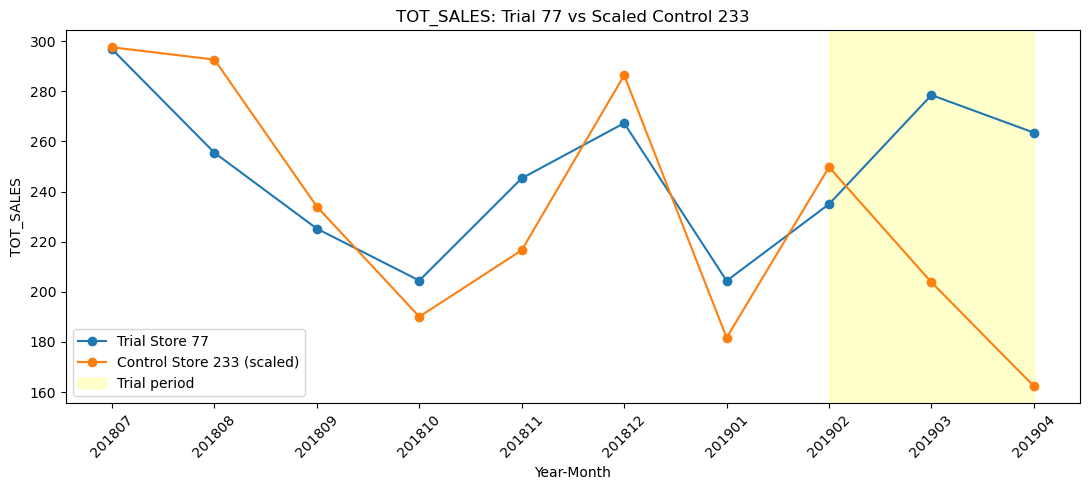

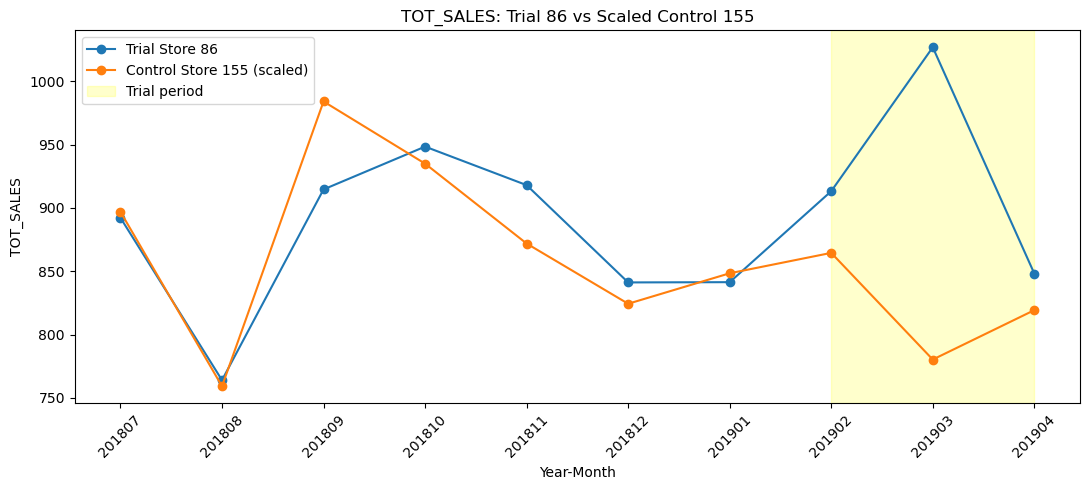

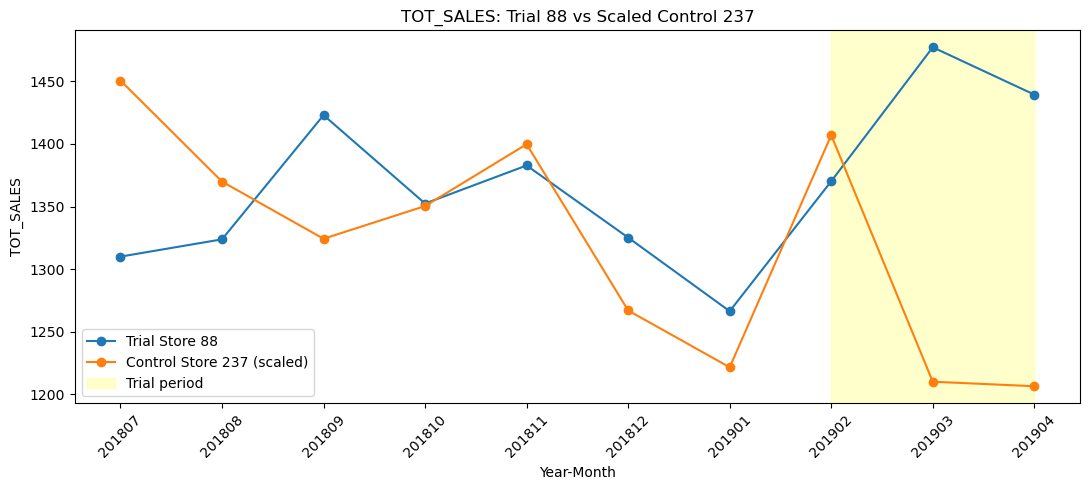

In [52]:
def plot_full_trial_chart(pretrial_df, trial_df, trial_store, control_store, metric_col="TOT_SALES"):
    scale = calc_scaling_factor(pretrial_df, trial_store, control_store, metric_col)
    
    full_data = pd.concat([pretrial_df, trial_df])
    trial_data = full_data[full_data["STORE_NBR"]==trial_store].sort_values("YEARMONTH")
    control_data = full_data[full_data["STORE_NBR"]==control_store].sort_values("YEARMONTH")
    
    plt.figure(figsize=(11,5))
    plt.plot(trial_data["YEARMONTH"].astype(str), trial_data[metric_col], marker="o", label=f"Trial Store {trial_store}")
    plt.plot(control_data["YEARMONTH"].astype(str), control_data[metric_col]*scale, marker="o", label=f"Control Store {control_store} (scaled)")
    plt.axvspan(7, 9, color="yellow", alpha=0.2, label="Trial period")  # Feb-Apr positions
    plt.title(f"{metric_col}: Trial {trial_store} vs Scaled Control {control_store}")
    plt.xlabel("Year-Month")
    plt.ylabel(metric_col)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_full_trial_chart(pretrial, trial_period, 77, 233, "TOT_SALES")
plot_full_trial_chart(pretrial, trial_period, 86, 155, "TOT_SALES")
plot_full_trial_chart(pretrial, trial_period, 88, 237, "TOT_SALES")

## Task 2 — Key Findings & Recommendation

**Methodology:**
- Control stores selected using a combined score (50% sales correlation/magnitude, 
  35% customer count, 15% avg transactions/customer) across the 7-month pre-trial 
  period (Jul 2018 - Jan 2019), validated visually before finalising.
- Control store pairs: Trial 77 ↔ Control 233, Trial 86 ↔ Control 155, Trial 88 ↔ Control 237
- Trial period (Feb-Apr 2019) sales were compared to scaled control store sales using 
  a t-test against pre-trial baseline variation (95% confidence).

**Results by store:**

*Store 77:* Significant sales uplift in March (+40%) and April (+66%), driven entirely 
by more customers visiting the store (customer count uplift matches the same months). 
No effect seen in February — likely an adjustment period.

*Store 86:* Significant sales uplift only in March (+28%). Customer numbers were up in 
all three trial months, but average spend per customer dropped in February and April, 
offsetting the extra footfall. This suggests the layout attracted visits but did not 
consistently convert to extra purchases in this store.

*Store 88:* Significant sales uplift in March (+22%) and April (+19%), consistent with 
increased customer numbers in the same months — a clean, customer-driven uplift 
similar to Store 77.

**Overall recommendation for Julia:**
2 of 3 trial stores (77 and 88) show a strong, consistent, statistically significant 
sales uplift driven by increased customer visits, with the effect strengthening over 
time. Store 86 shows a weaker and less consistent result, suggesting the layout's 
success may depend on store-specific factors (e.g. local customer base, store size, 
or execution consistency).

We recommend a broader rollout of the trial layout, with store 86's result flagged 
for further investigation (e.g. was the layout implemented correctly there, or does 
this store's customer base behave differently) before committing to a full chain-wide rollout.

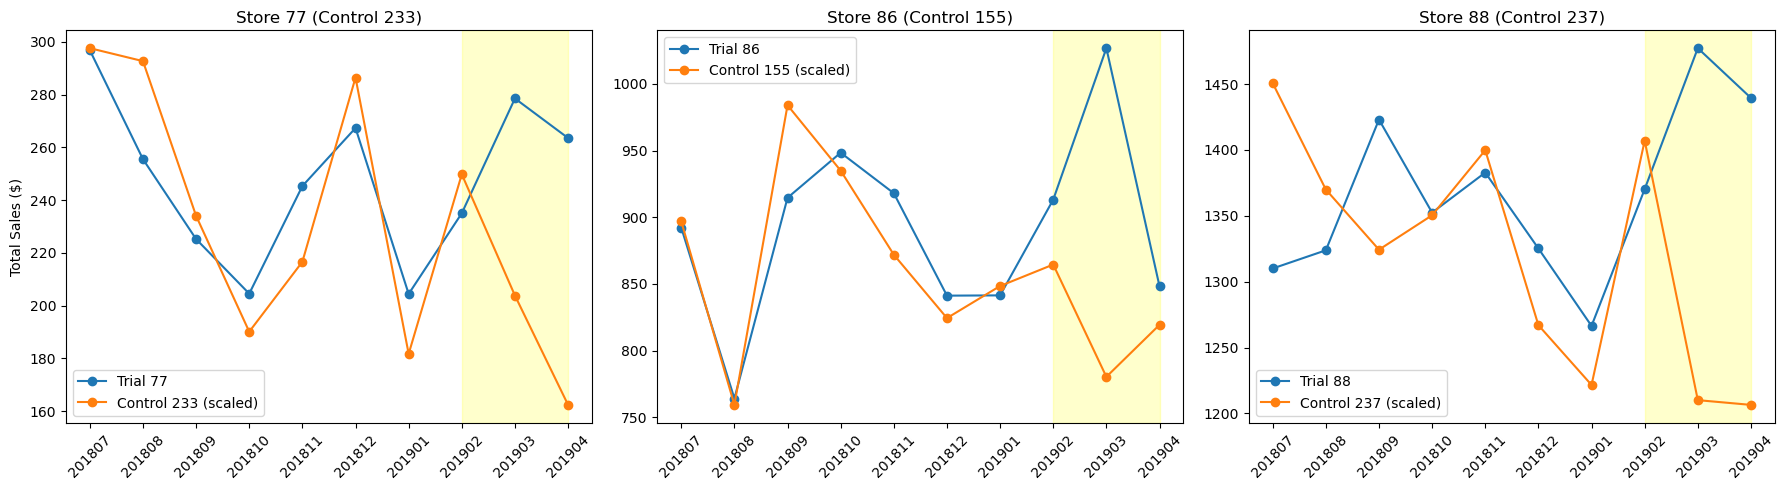

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, (trial, control) in zip(axes, pairs):
    scale = calc_scaling_factor(pretrial, trial, control, "TOT_SALES")
    full_data = pd.concat([pretrial, trial_period])
    
    trial_data = full_data[full_data["STORE_NBR"]==trial].sort_values("YEARMONTH")
    control_data = full_data[full_data["STORE_NBR"]==control].sort_values("YEARMONTH")
    
    ax.plot(trial_data["YEARMONTH"].astype(str), trial_data["TOT_SALES"], marker="o", label=f"Trial {trial}")
    ax.plot(control_data["YEARMONTH"].astype(str), control_data["TOT_SALES"]*scale, marker="o", label=f"Control {control} (scaled)")
    ax.axvspan(7, 9, color="yellow", alpha=0.2)
    ax.set_title(f"Store {trial} (Control {control})")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
    ax.legend()

axes[0].set_ylabel("Total Sales ($)")
plt.tight_layout()
plt.savefig("slide10_chart.png", dpi=150)
plt.show()

In [ ]:
==